In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# eliminam formatul stiintific pentru probabilitati
np.set_printoptions(suppress=True)

# incarcam datele
df = pd.read_csv('data/Teen_Mental_Health_Dataset.csv')

# eliminam atributele stress_level, anxiety_level si addiction_level
df = df.drop(['stress_level', 'anxiety_level', 'addiction_level'], axis=1)

# transformam variabile text in numerice
def encode_text(df, columns):
    le = LabelEncoder()
    for col in columns:
        df[col] = le.fit_transform(df[col])
    return df

categoriale = ['gender', 'platform_usage', 'social_interaction_level']
df = encode_text(df, categoriale)

# separare X (atribute) si y (scop)
X = df.drop('depression_label', axis=1).values.astype(np.float32)
y = df['depression_label'].values.astype(np.float32)

# standardizam datele
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# functie pentru rularea experimentului Naive Bayes
def experiment_naive_bayes(k_val, nume_exp):
    print(f"\n\n--- {nume_exp} ---")
    
    gnb = GaussianNB()
    kf = KFold(n_splits=k_val, shuffle=True, random_state=42)
    
    # predictiile modelului prin k-fold
    y_pred = cross_val_predict(gnb, X_std, y, cv=kf)
    
    # calcularea probabilitatilor
    y_proba = cross_val_predict(gnb, X_std, y, cv=kf, method='predict_proba')

    # afisarea claselor si a probabilitatilor pentru primele instante
    # (antrenam modelul pe tot setul doar pentru a vedea clasele)
    gnb.fit(X_std, y)
    print('\nClasele:', gnb.classes_)
    print('Probabilitatile pentru primele 5 instante test (%):\n', y_proba[:5] * 100)

    # numararea instantelor clasificate gresit
    print("\nInstante clasificate gresit dintr-un total de %d inregistrari : %d" % (len(y), (y != y_pred).sum()))

    # acuratetea de clasificare
    print("Acuratetea de clasificare = % 5.2f" % accuracy_score(y, y_pred))
    
    # afisare raport de clasificare
    print("\nRaportul de clasificare:")
    print(classification_report(y, y_pred))
    
    # matricea de confuzie
    cm = confusion_matrix(y, y_pred)
    print('Matricea de confuzie:\n', cm)
    
    # reprezentare grafica
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # matricea de confuzie grafica
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax[0], cmap='Greens')
    ax[0].set_title(f"Matrice Confuzie {nume_exp}")
    
    # comparare valori reale vs predictii (esantion 50 instante)
    t = pd.DataFrame({'real': y[:50], 'predit': y_pred[:50]})
    ax[1].plot(t['real'].tolist(), label='Real', marker='o', linestyle='')
    ax[1].plot(t['predit'].tolist(), label='Predit', marker='x', linestyle='')
    ax[1].set_title("Real vs Predictie NB")
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()



--- Experiment_1 ---

Clasele: [0. 1.]
Probabilitatile pentru primele 5 instante test (%):
 [[ 99.9999925    0.0000075 ]
 [100.           0.        ]
 [100.           0.        ]
 [ 99.95117454   0.04882546]
 [ 94.2959745    5.7040255 ]]

Instante clasificate gresit dintr-un total de 1200 inregistrari : 37
Acuratetea de clasificare =  0.97

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1163    6]
 [  31    0]]


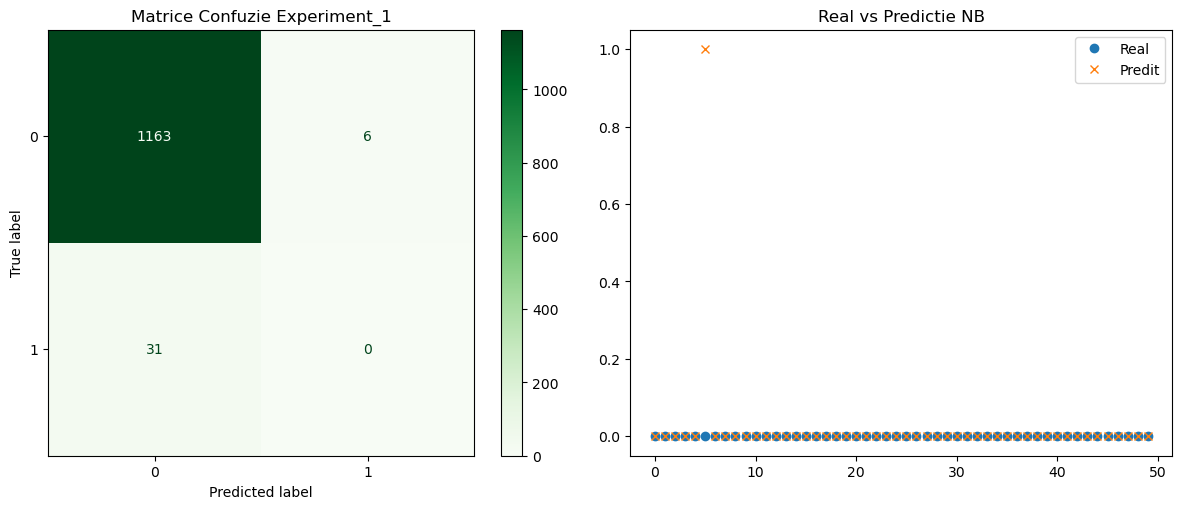

In [7]:
# experiment 1
experiment_naive_bayes(k_val=5, nume_exp="Experiment_1")



--- Experiment_2 ---

Clasele: [0. 1.]
Probabilitatile pentru primele 5 instante test (%):
 [[ 99.99976293   0.00023707]
 [100.           0.        ]
 [100.           0.        ]
 [ 99.96257955   0.03742045]
 [ 95.29571939   4.70428061]]

Instante clasificate gresit dintr-un total de 1200 inregistrari : 33
Acuratetea de clasificare =  0.97

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1167    2]
 [  31    0]]


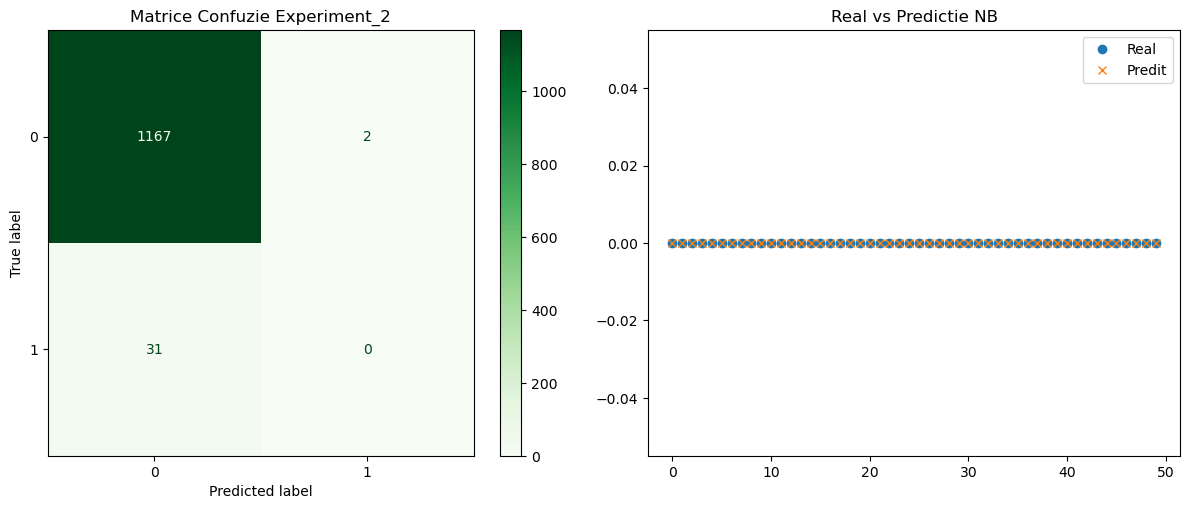

In [6]:
# experiment 2
experiment_naive_bayes(k_val=10, nume_exp="Experiment_2")



--- Experiment_3 ---

Clasele: [0. 1.]
Probabilitatile pentru primele 5 instante test (%):
 [[ 99.99998044   0.00001956]
 [100.           0.        ]
 [100.           0.        ]
 [ 99.96439601   0.03560399]
 [ 98.14964864   1.85035136]]

Instante clasificate gresit dintr-un total de 1200 inregistrari : 38
Acuratetea de clasificare =  0.97

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1162    7]
 [  31    0]]


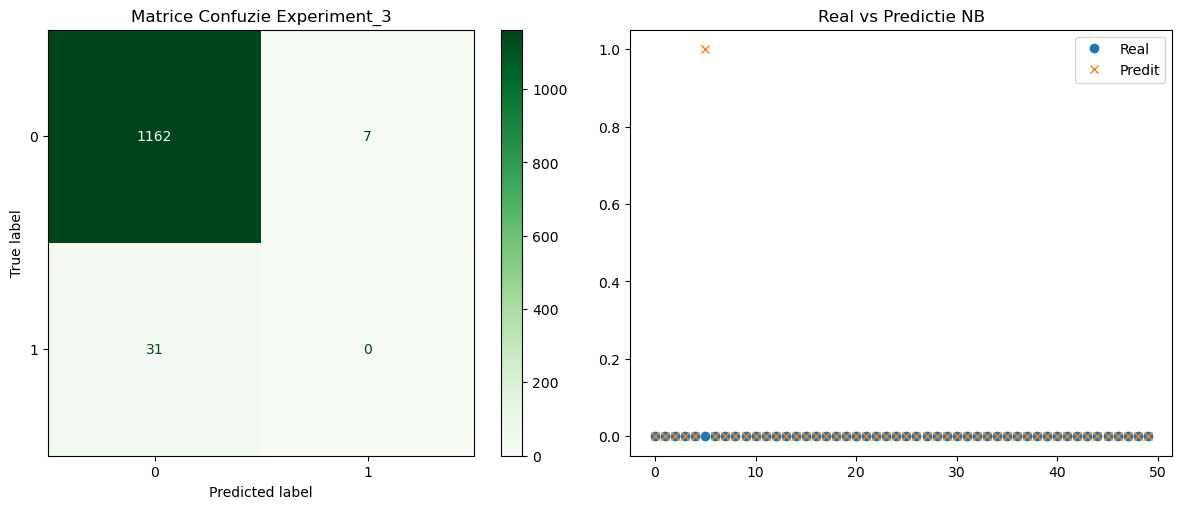

In [5]:
# experiment 3
experiment_naive_bayes(k_val=3, nume_exp="Experiment_3")